In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [3]:
SEED = 42
IMG_SIZE = (32, 32)
BATCH_SIZE = 128
EPOCHS = 20

np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = Path("Documents/AI VS REAL IMAGE/train")

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))
print("Train folder exists:", TRAIN_DIR.exists())

TensorFlow version: 2.21.0
GPU available: False
Train folder exists: False


In [4]:
TRAIN_DIR = Path(r"C:\Users\hp\Documents\AI VS REAL IMAGE\train")

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def count_images(folder):
    return sum(
        1 for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

REAL_DIR = TRAIN_DIR / "REAL"
FAKE_DIR = TRAIN_DIR / "FAKE"

print("REAL images:", count_images(REAL_DIR))
print("FAKE images:", count_images(FAKE_DIR))

REAL images: 50000
FAKE images: 50000


In [6]:
CLASS_NAMES = ["REAL", "FAKE"]

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.


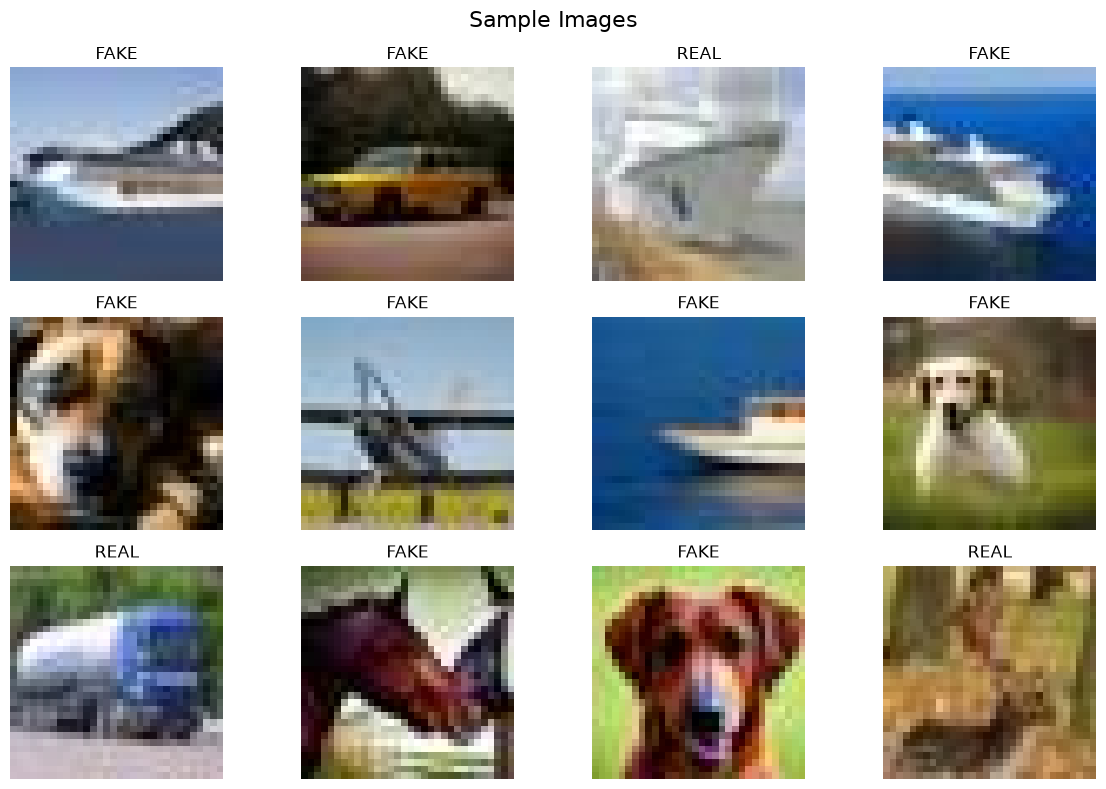

In [7]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for index in range(min(12, len(images))):
        plt.subplot(3, 4, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        label = int(labels[index].numpy().item())
        plt.title("FAKE" if label == 1 else "REAL")
        plt.axis("off")
plt.suptitle("Sample Images", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ---- Part 1: Setup ----
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

warnings.filterwarnings("ignore")
SEED = 42
IMG_SIZE = (32, 32)
BATCH_SIZE = 128
EPOCHS = 20
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = Path(r"C:\Users\hp\Documents\AI VS REAL IMAGE\train")  # adjust path

# ---- Part 2: Load Data ----
CLASS_NAMES = ["REAL", "FAKE"]

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, class_names=CLASS_NAMES, labels="inferred", label_mode="binary",
    validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, class_names=CLASS_NAMES, labels="inferred", label_mode="binary",
    validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ---- Part 4: Build Model ----
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="reflect"),
], name="data_augmentation")

inputs = tf.keras.Input(shape=(32, 32, 3), name="input_image")
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1.0 / 255, name="normalization")(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="ai_probability")(x)
model = tf.keras.Model(inputs, outputs, name="ai_detector")

# ---- Part 5: Compile ----
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1,
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", monitor="val_loss", save_best_only=True, verbose=1,
)

# ---- Train ----
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint],
    verbose=1,
)

Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7634 - auc: 0.8485 - loss: 0.4861 - precision: 0.7847 - recall: 0.7271
Epoch 1: val_loss improved from None to 0.41217, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 156ms/step - accuracy: 0.7634 - auc: 0.8485 - loss: 0.4861 - precision: 0.7847 - recall: 0.7271 - val_accuracy: 0.8287 - val_auc: 0.9223 - val_loss: 0.4122 - val_precision: 0.7698 - val_recall: 0.9345
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8320 - auc: 0.9110 - loss: 0.3812 - precision: 0.8411 - recall: 0.8195
Epoch 2: val_loss did not improve from 0.41217
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.8320 - auc: 0.9110 - loss: 0.3812 - precision: 0.8411 - recall: 0.8195 - val_accuracy: 0.8245 - 

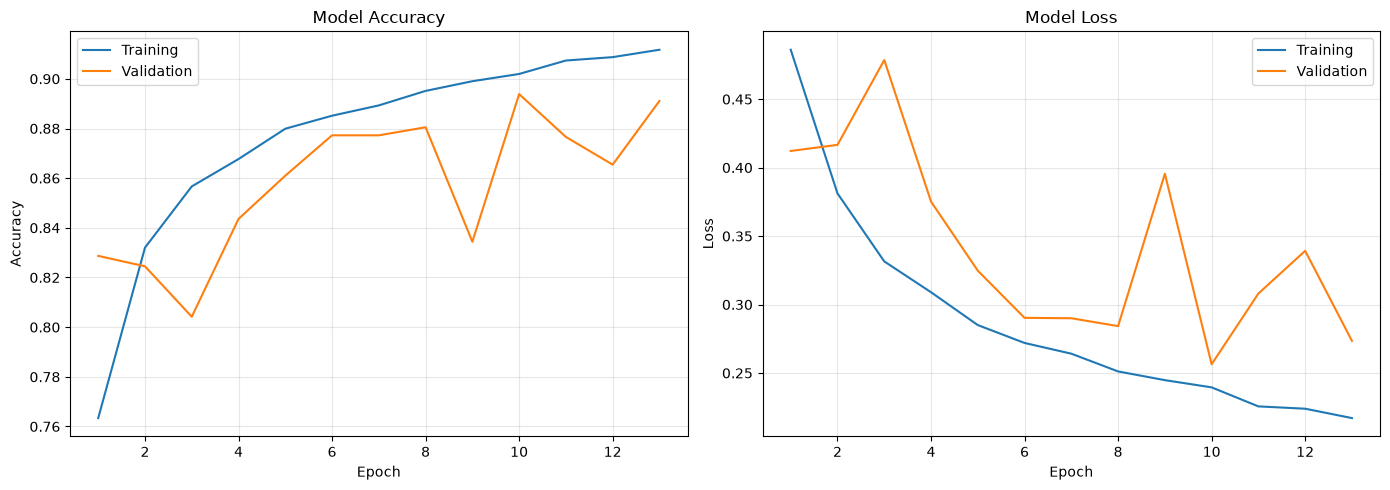

In [21]:
epochs_completed = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_completed, history.history["accuracy"], label="Training")
plt.plot(epochs_completed, history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_completed, history.history["loss"], label="Training")
plt.plot(epochs_completed, history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
TEST_DIR = Path(r"C:\Users\hp\Documents\AI VS REAL IMAGE\test")  # adjust path

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASS_NAMES,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 20000 files belonging to 2 classes.


157/157 ━━━━━━━━━━━━━━━━━━━━ 98s 620ms/step - accuracy: 0.8995 - auc: 0.9766 - loss: 0.2472 - precision: 0.8505 - recall: 0.9692

EVALUATION RESULTS
ACCURACY  : 0.8995
AUC       : 0.9766
LOSS      : 0.2472
PRECISION : 0.8505
RECALL    : 0.9692
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step

F1 score: 0.9060060761860248
ROC-AUC: 0.977149735

               precision    recall  f1-score   support

        REAL     0.9642    0.8297    0.8919     10000
        FAKE     0.8505    0.9692    0.9060     10000

    accuracy                         0.8994     20000
   macro avg     0.9074    0.8994    0.8990     20000
weighted avg     0.9074    0.8994    0.8990     20000



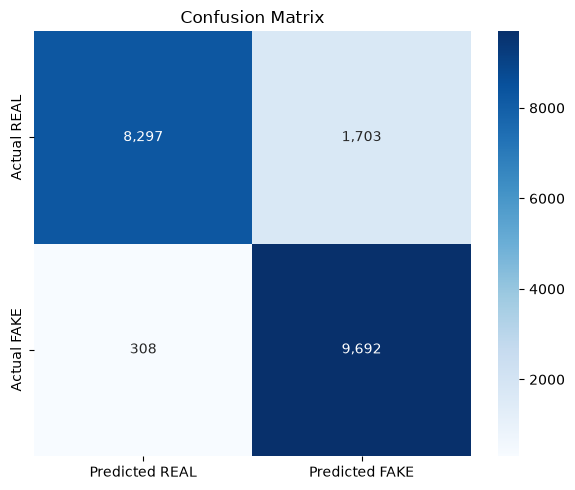

In [25]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
import seaborn as sns

eval_ds = test_ds  # change to val_ds if you don't have a test folder

results = model.evaluate(eval_ds, return_dict=True, verbose=1)
print("\nEVALUATION RESULTS")
for name, value in results.items():
    print(f"{name.upper():10s}: {value:.4f}")

y_true = np.concatenate([labels.numpy().reshape(-1) for _, labels in eval_ds]).astype(int)
y_probability = model.predict(eval_ds, verbose=1).reshape(-1)
y_predicted = (y_probability >= 0.50).astype(int)

print("\nF1 score:", f1_score(y_true, y_predicted))
print("ROC-AUC:", roc_auc_score(y_true, y_probability))
print("\n", classification_report(y_true, y_predicted, target_names=["REAL", "FAKE"], digits=4))

matrix = confusion_matrix(y_true, y_predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Predicted REAL", "Predicted FAKE"],
            yticklabels=["Actual REAL", "Actual FAKE"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Prediction: FAKE
Confidence: 75.08%


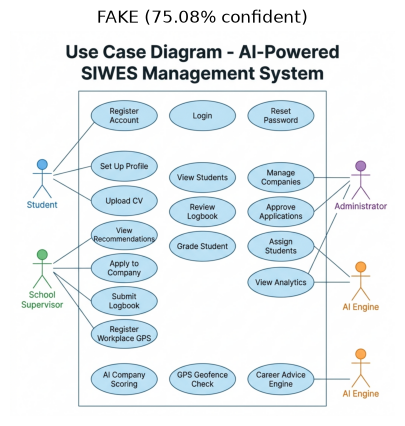

('FAKE', 0.750752866268158)

In [47]:
def predict_image(image_path, threshold=0.50):
    image_path = Path(image_path)
    original = tf.keras.utils.load_img(image_path)
    resized = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
    image_array = tf.keras.utils.img_to_array(resized)
    image_array = np.expand_dims(image_array, axis=0)
    probability_fake = float(model.predict(image_array, verbose=0)[0][0])

    prediction = "FAKE" if probability_fake >= threshold else "REAL"
    confidence = probability_fake if prediction == "FAKE" else 1 - probability_fake

    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2%}")

    plt.figure(figsize=(5, 5))
    plt.imshow(original)
    plt.title(f"{prediction} ({confidence:.2%} confident)")
    plt.axis("off")
    plt.show()

    return prediction, confidence

# Example usage:
predict_image(r"C:\Users\hp\Downloads\SIWES_Use_Case_Diagram.png")

In [37]:
from pathlib import Path
print(Path("best_model.keras").exists())
print(Path("best_model.keras").stat().st_size / (1024*1024), "MB")

True
1.123946189880371 MB
